# Sample-level & outlier views

Interactive driver for `analysis/profiles/plots.py`.

Select the dataset (or pooled set) with the `DATASET` env var **before launching Jupyter**, e.g.
`DATASET=alphaseq jupyter lab`, or set `base` by hand in the load cell below.
Cross-metric figures (clustermap / filter / profiles) use the standardized+aligned table;
`per_dataset` and `outliers` use the raw values.

In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from analysis.distributions.wide import add_binder_type
from config.paths import RAW_DATA_DIR
from config.datasets import cfg
from analysis.distributions.profiles import (
    plot_sample_clustermap, plot_filter_heatmap, load_thresholds, plot_sample_profiles,
    plot_per_dataset, plot_outliers, outlier_table, cluster_association,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# pick the dataset directory 
base = RAW_DATA_DIR / cfg.name               # cluster: set DATASET=... before launch
# base = Path("data/raw/alphaseq")           # local override, if not using config paths

raw = add_binder_type(pd.read_csv(base / "merged.csv"))
sa = base / "merged_scaled_aligned.csv"
if not sa.exists():                          # scaling must be done up front (run_scale.py)
    raise FileNotFoundError(f"{sa} not found - run run_scale.py first; profiles expect a scaled+aligned table.")
scaled = add_binder_type(pd.read_csv(sa))
print(base.name, "| samples:", len(raw), "| classes:", raw["binder_type"].value_counts().to_dict())

current | samples: 163 | classes: {'Design': 83, 'Binder': 36, 'Mutant+': 21, 'Mutant-': 12, 'Non-Binder': 11}


## 1. Sample × metric clustermap  (standardized, aligned)

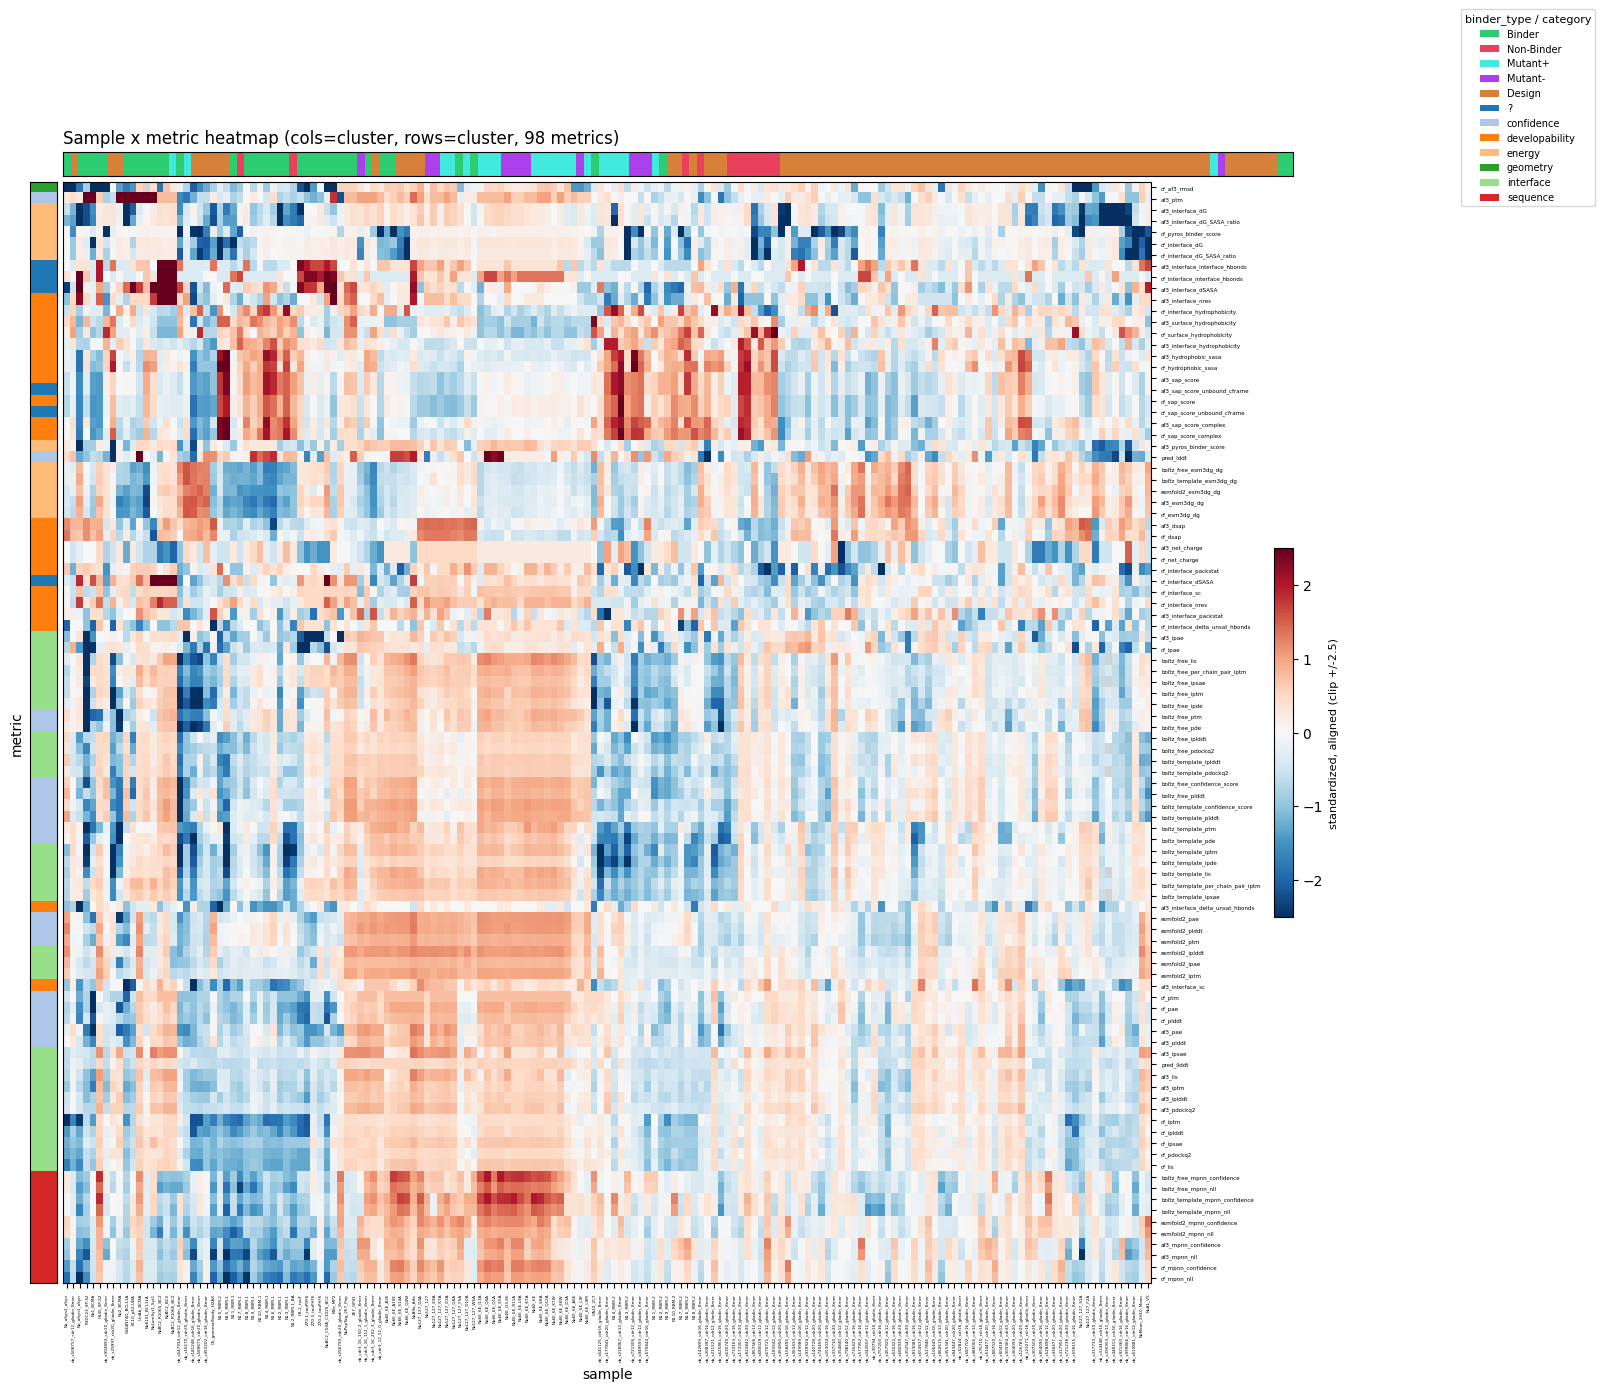

In [ ]:
plot_sample_clustermap(scaled);

## 2. Boolean filter matrix  (per-metric median = placeholder cutoff)

/scicore/home/schwede/barta0000/project/analysis/profiles/plots.py:228: UserWarning: plot_filter_heatmap: 6 column(s) match no metric_data family and are dropped: af3_interface_dSASA, af3_interface_interface_hbonds, cf_interface_dSASA, cf_interface_interface_hbonds, af3_sap_score_unbound_cframe, cf_sap_score_unbound_cframe
  import warnings; warnings.warn(f"plot_filter_heatmap: {len(unmatched)} column(s) match no metric_data family "


no threshold (skipped): ['hydrophobic_sasa', 'interface_dG', 'interface_dG_SASA_ratio', 'interface_hydrophobicity']
unmatched columns (dropped): ['af3_interface_dSASA', 'af3_interface_interface_hbonds', 'cf_interface_dSASA', 'cf_interface_interface_hbonds', 'af3_sap_score_unbound_cframe', 'cf_sap_score_unbound_cframe']


/scicore/home/schwede/barta0000/project/analysis/profiles/plots.py:228: UserWarning: plot_filter_heatmap: 6 column(s) match no metric_data family and are dropped: af3_interface_dSASA, af3_interface_interface_hbonds, cf_interface_dSASA, cf_interface_interface_hbonds, af3_sap_score_unbound_cframe, cf_sap_score_unbound_cframe
  import warnings; warnings.warn(f"plot_filter_heatmap: {len(unmatched)} column(s) match no metric_data family "


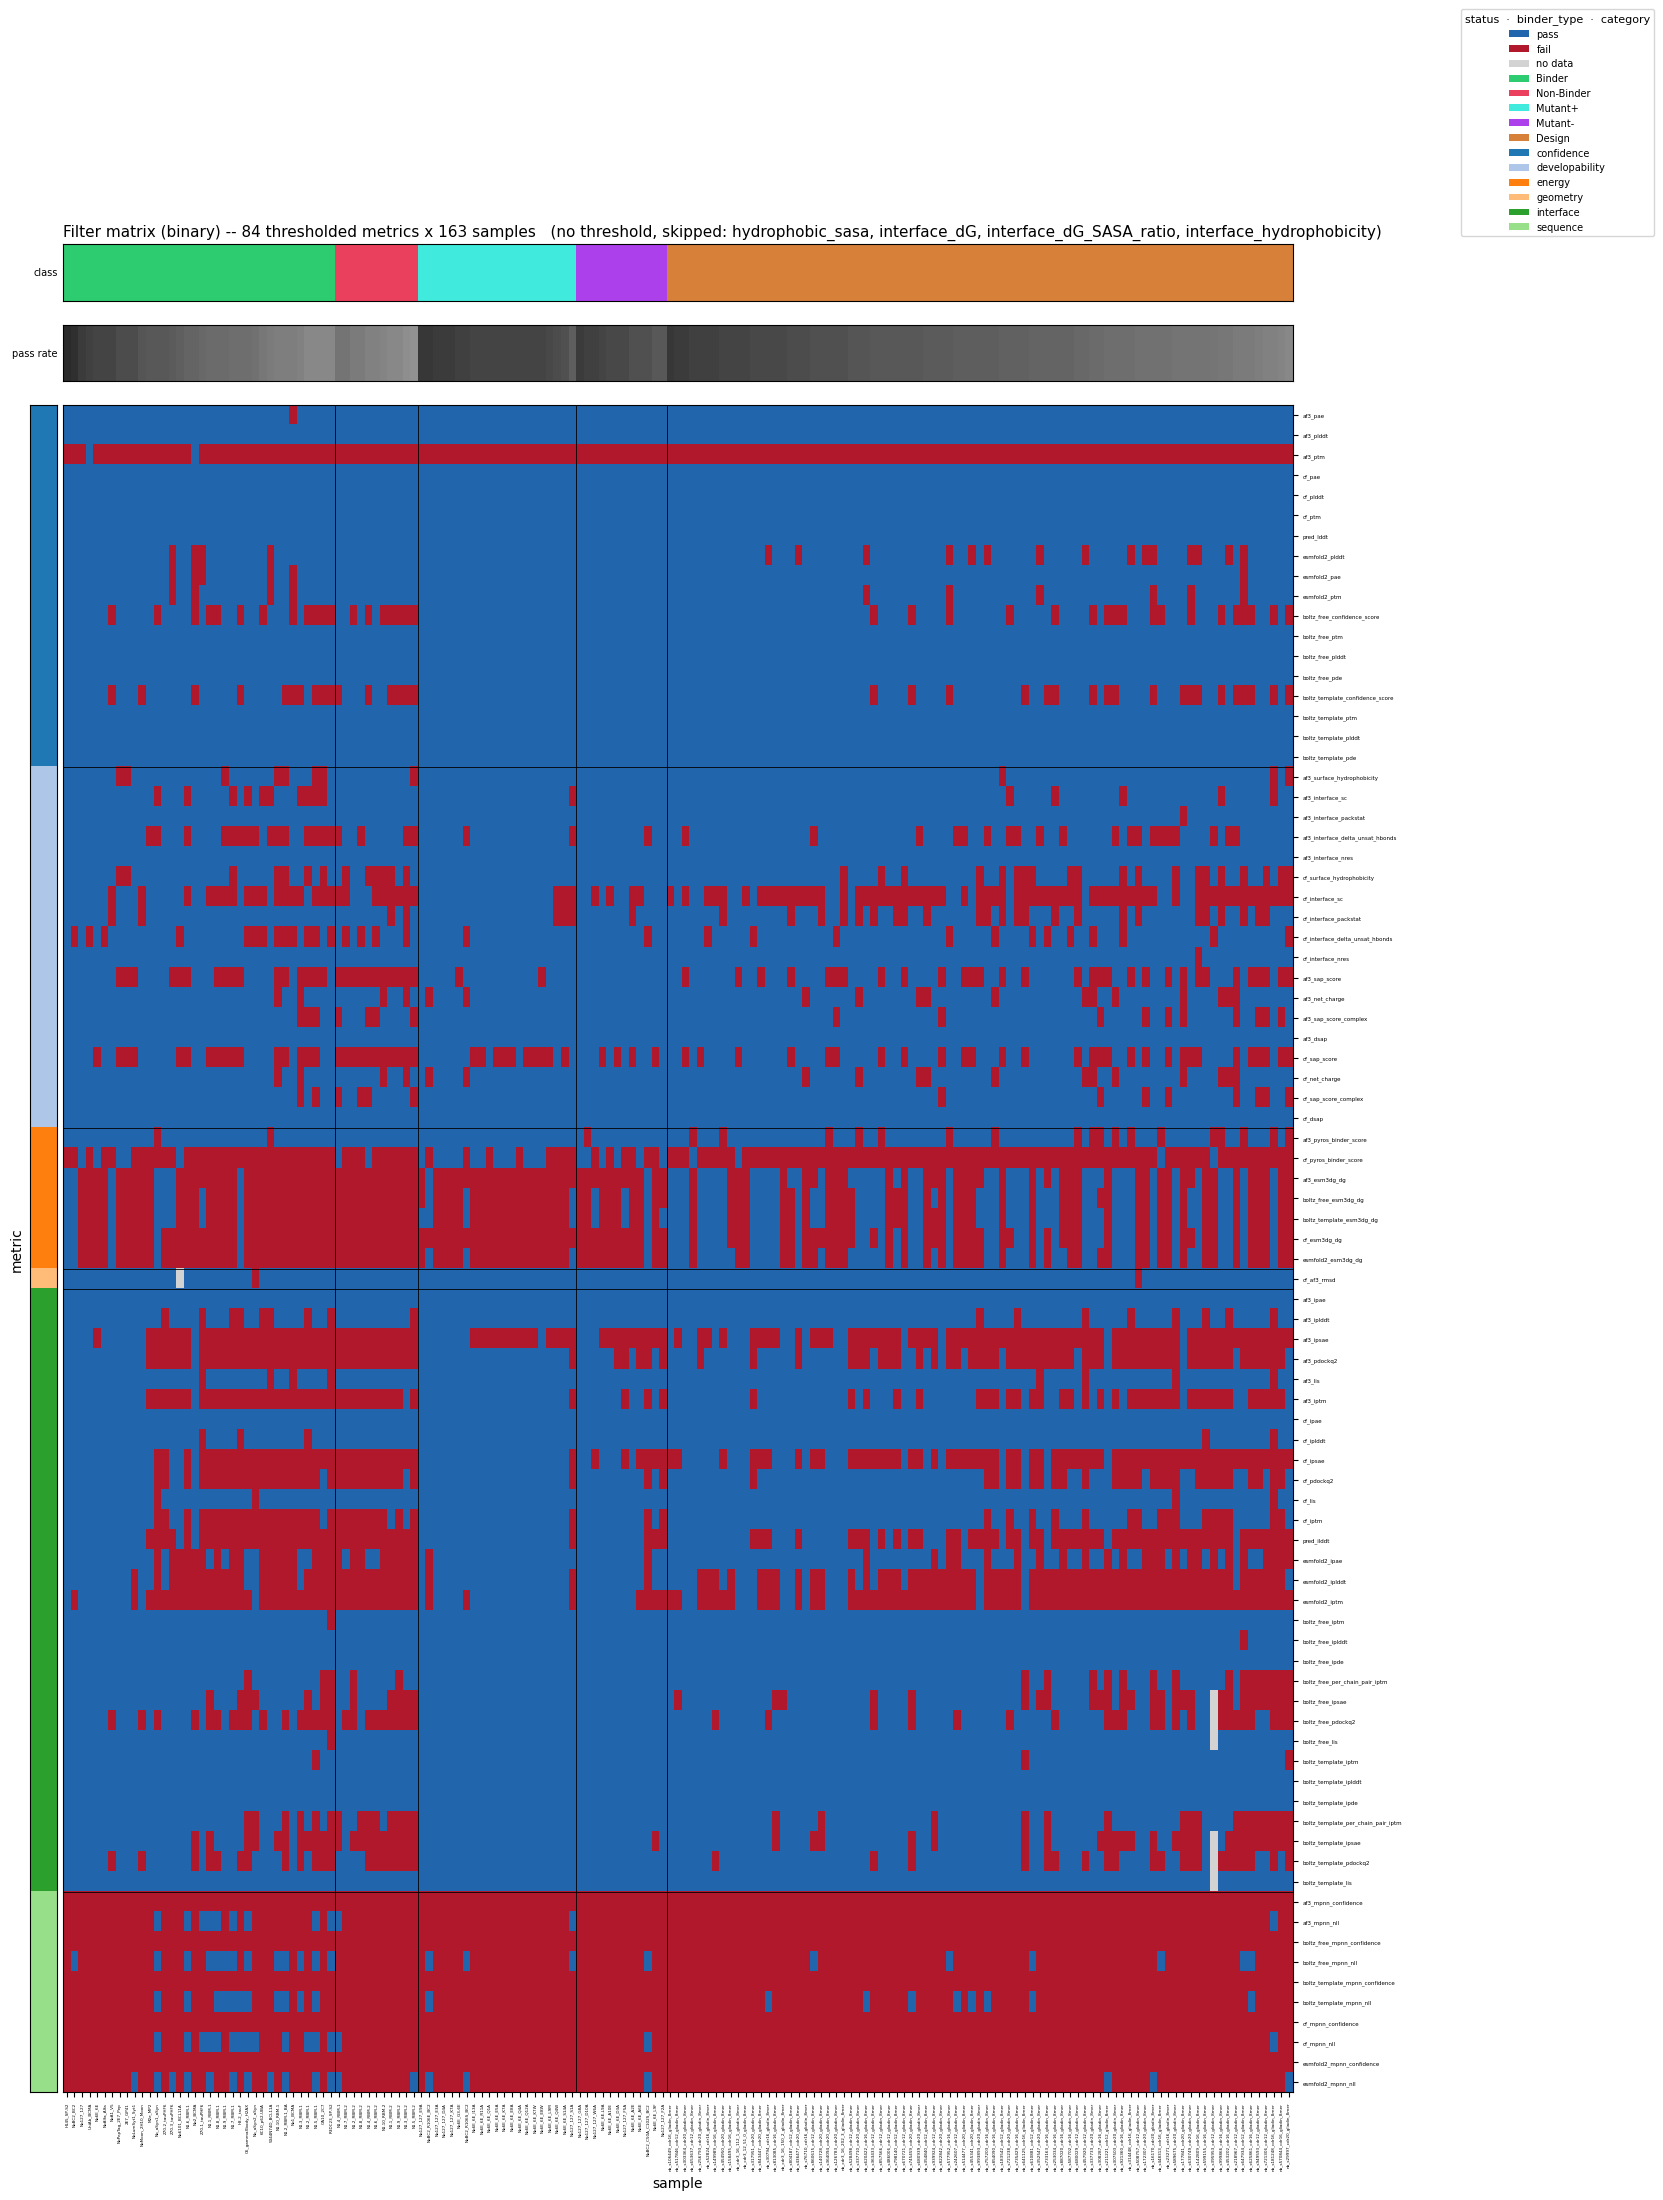

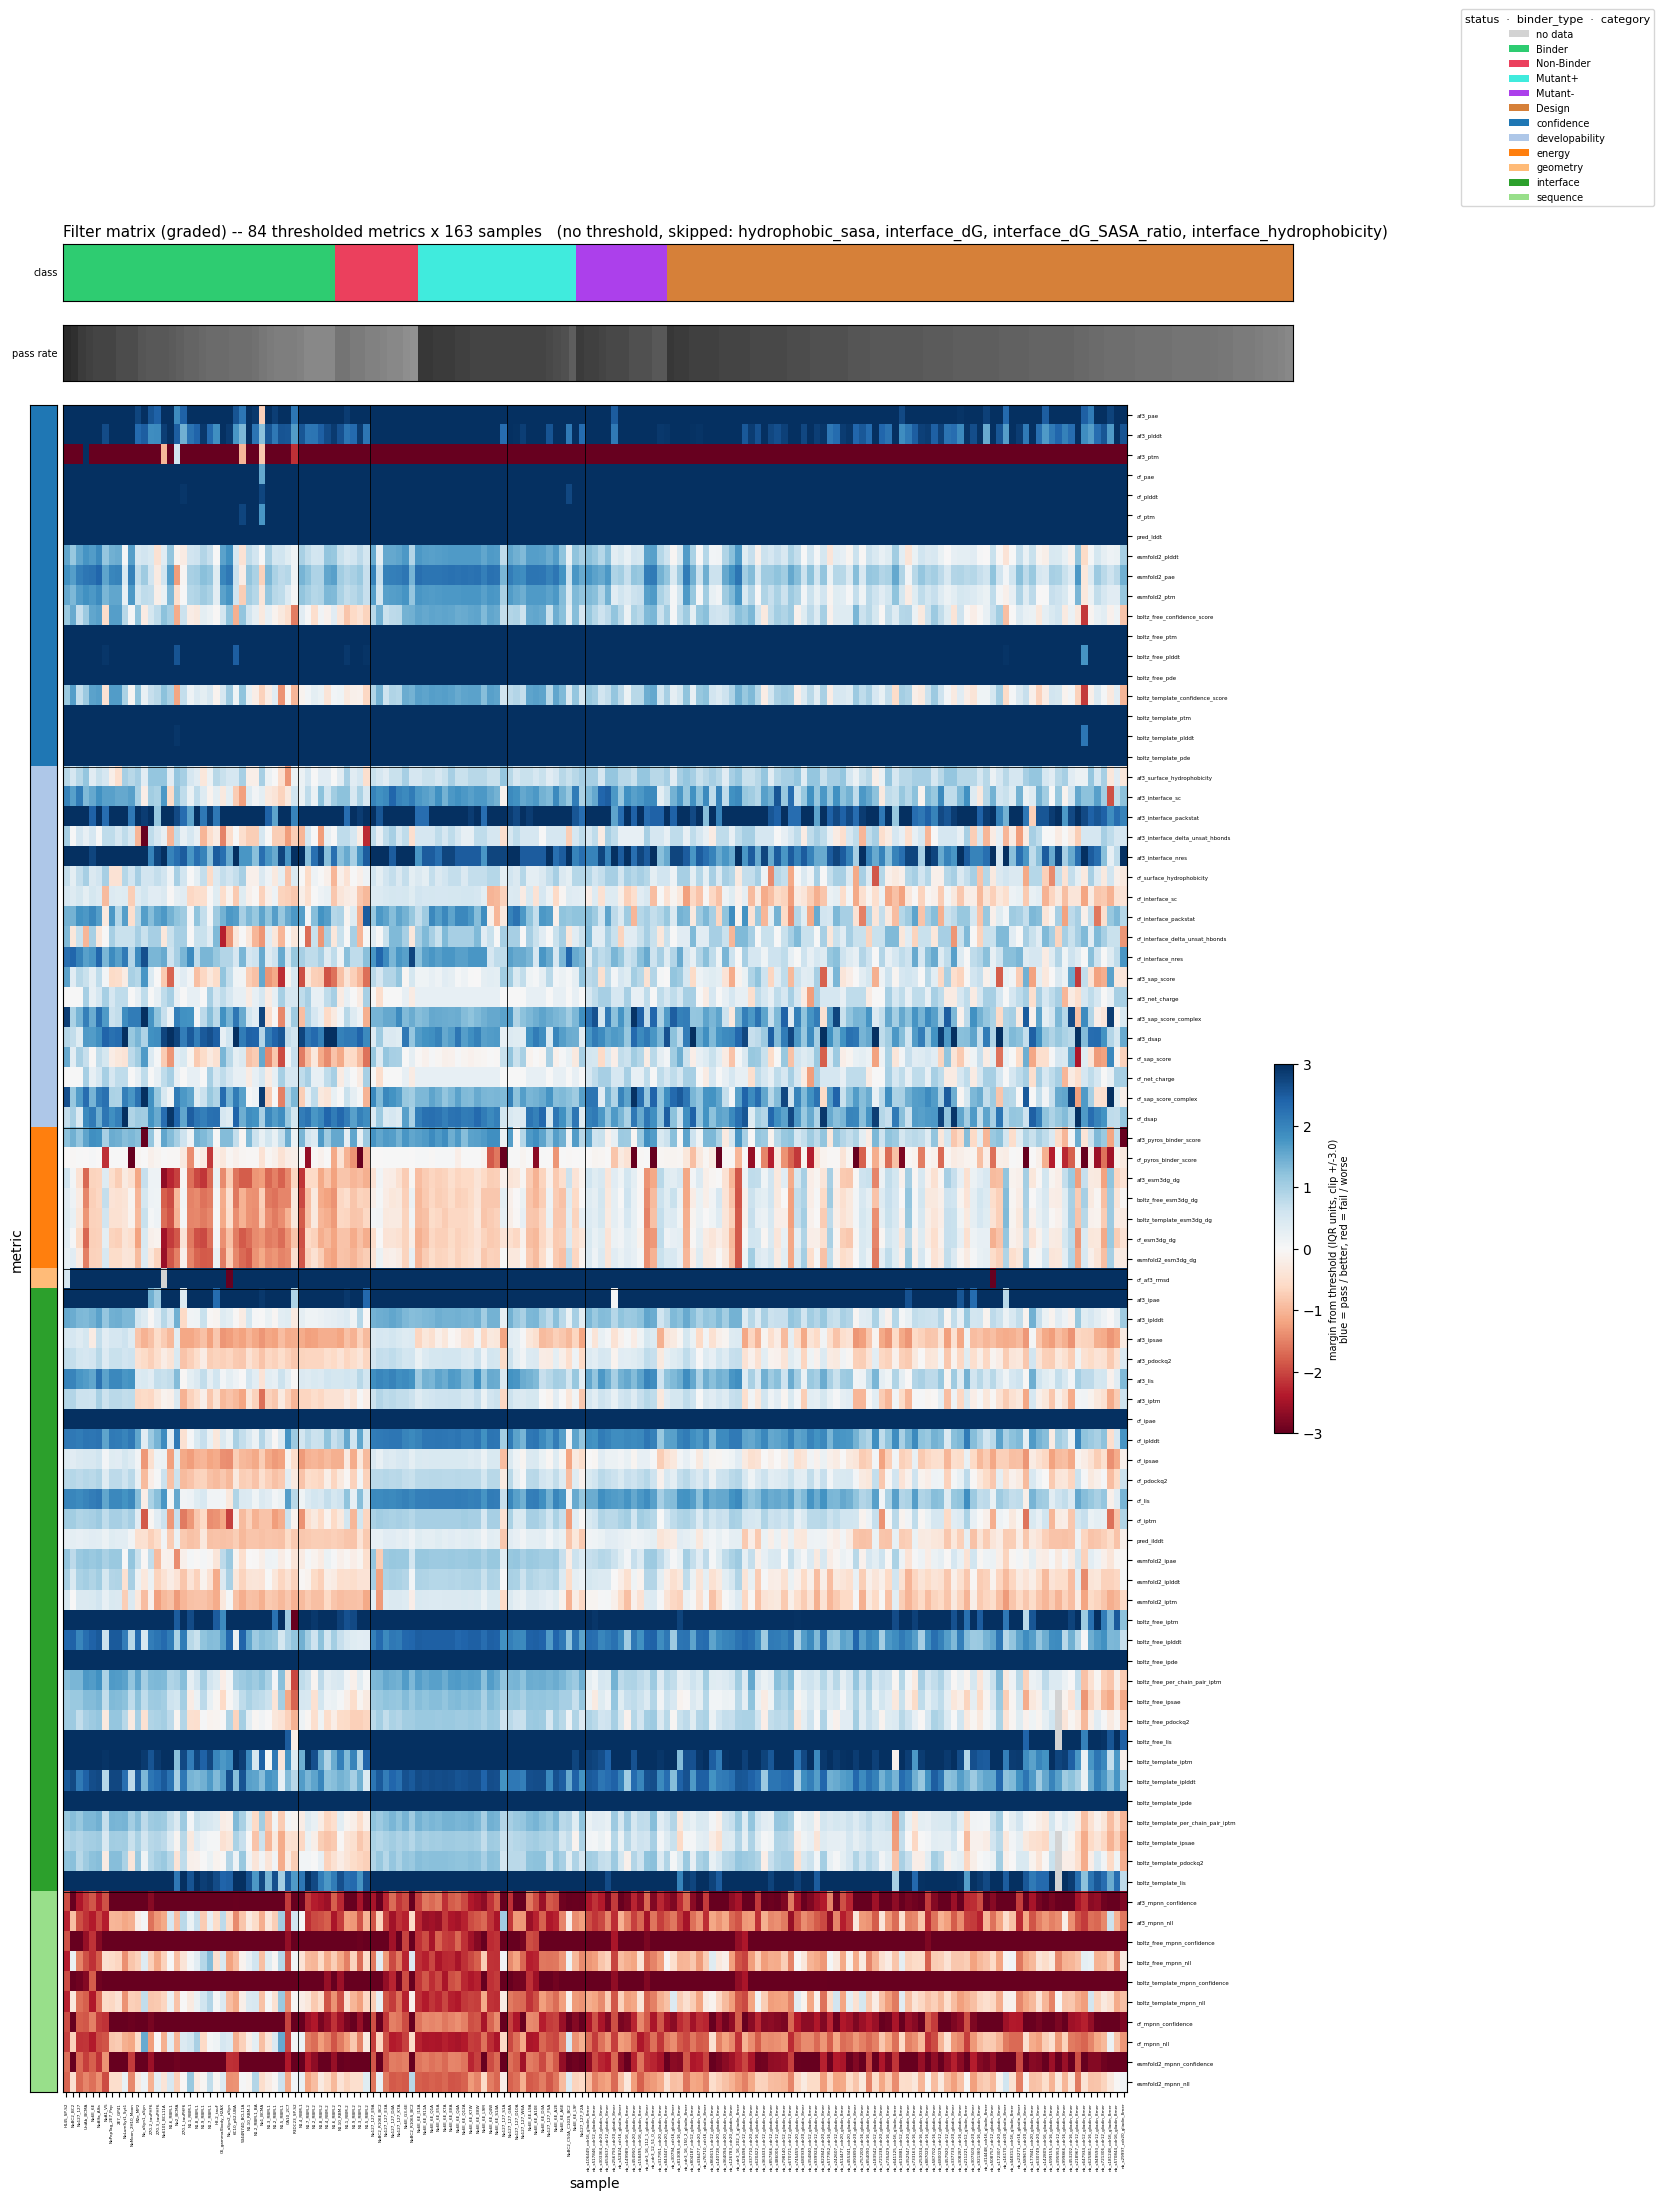

In [ ]:
thr = load_thresholds("/scicore/home/schwede/barta0000/project/config/thresholds.yaml")
fig, report = plot_filter_heatmap(raw, thr)                 # binary pass/fail
print("no threshold (skipped):", report["no_threshold"])
print("unmatched columns (dropped):", report["unmatched"])
plot_filter_heatmap(raw, thr, mode="graded")              # graded: margin from threshold (blue=pass, red=fail)

## 3. Selected-sample profiles vs group bands

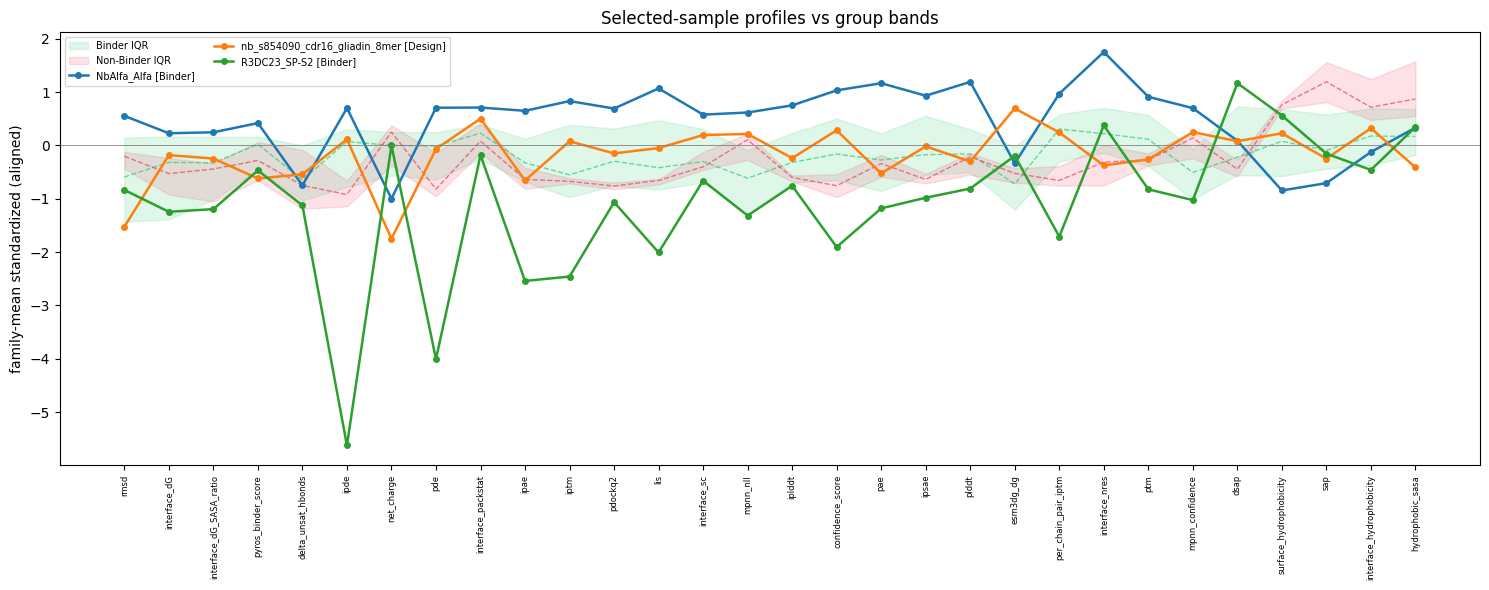

In [ ]:
plot_sample_profiles(scaled, n=3);

## 4. Per-dataset distribution  (raw values; facets on `dataset` else `source`)

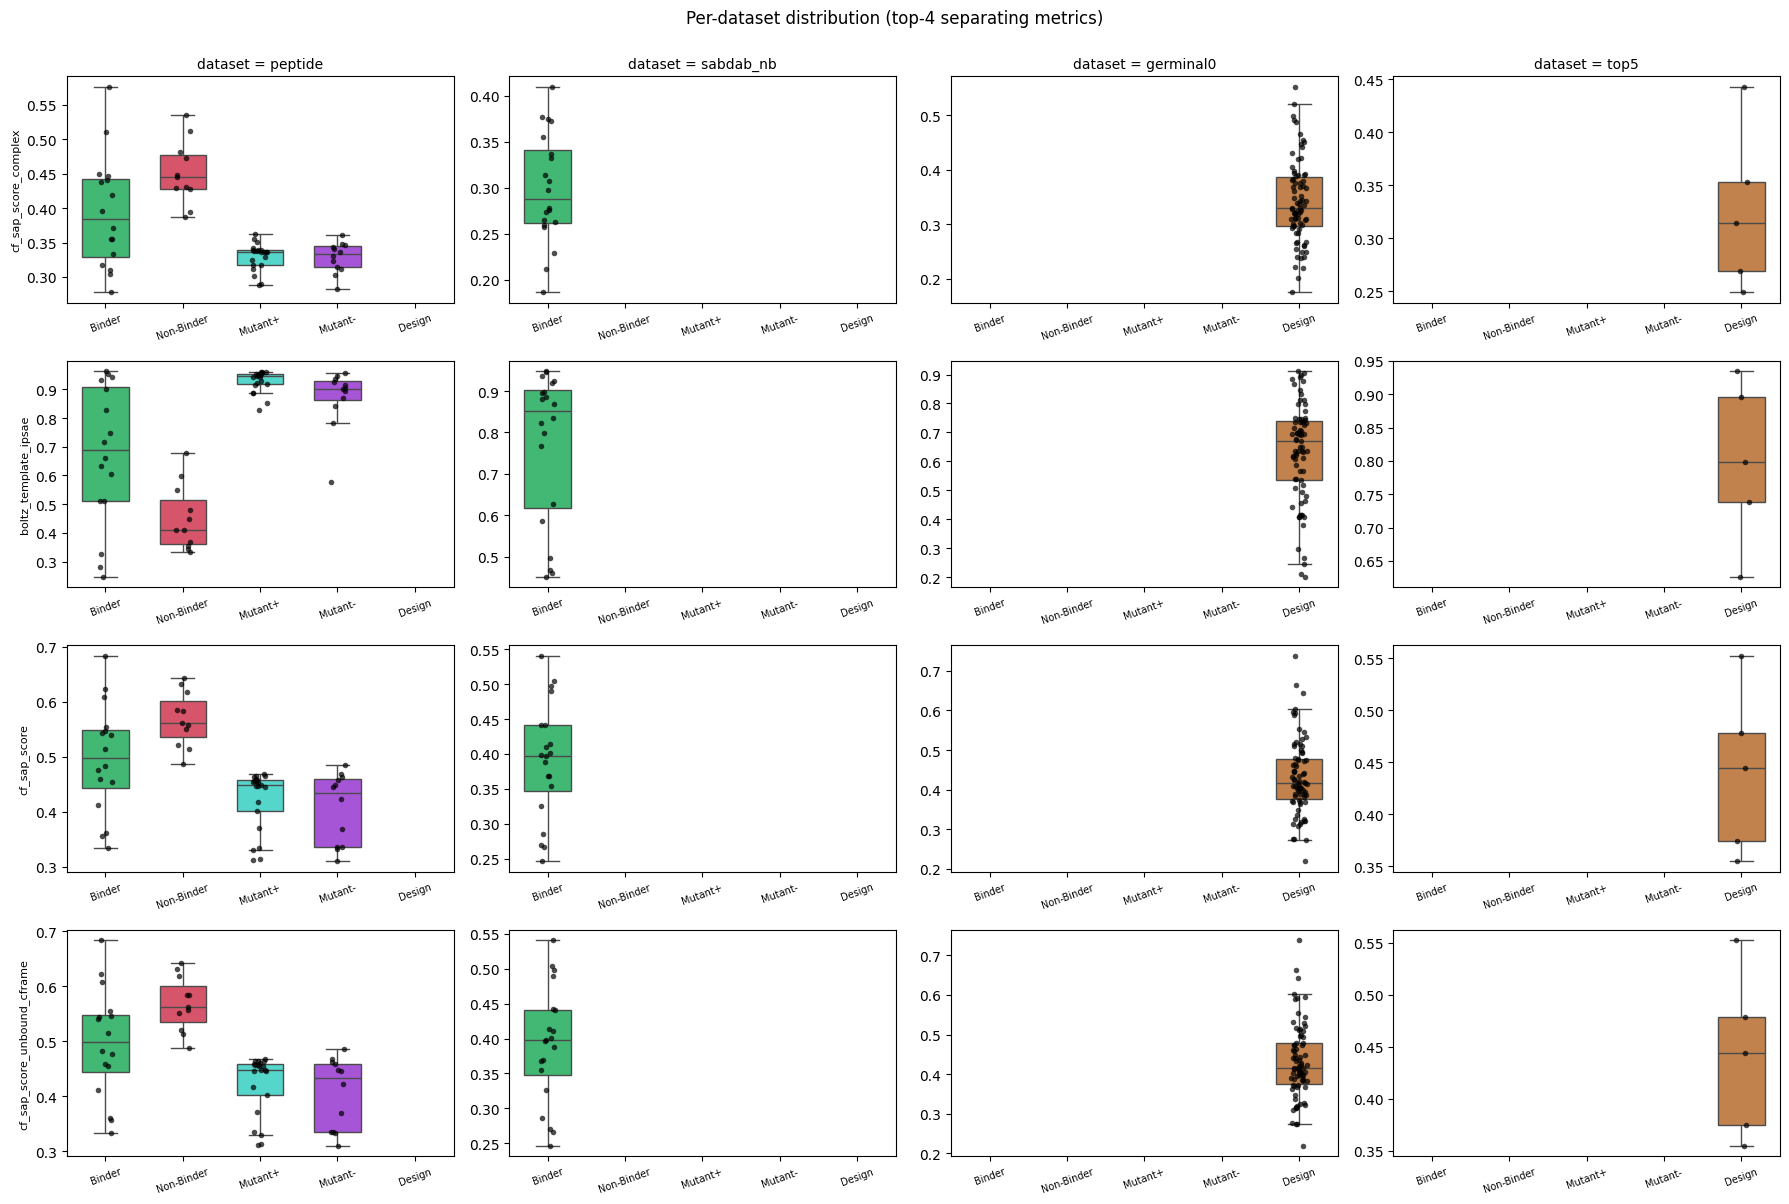

In [ ]:
plot_per_dataset(raw, top=4);

## 5. Outlier / scale inspection

Change `scale` to `error` / `likelihood` / `distance` / `ratio` to inspect the other families.
The table gives the robust (median/IQR) outlier flag counts; the plot shows whether the
spread is cross-model **scale** or true outliers.

,metric,min,median,max,neg,n_outliers
0,cf_pyros_binder_score,-140.26,571.32,41110.00,30,4
1,cf_interface_dG,-9.78,629.84,14677.07,8,4
2,af3_interface_dG,-20.07,22.39,1226.67,23,2
3,af3_pyros_binder_score,-213.92,-121.00,787.22,142,2
4,cf_esm3dg_dg,0.13,1.99,4.50,0,0
5,esmfold2_esm3dg_dg,0.17,1.88,4.48,0,0
6,af3_esm3dg_dg,0.23,1.87,4.30,0,0
7,boltz_free_esm3dg_dg,-0.08,1.79,3.89,1,0
8,boltz_template_esm3dg_dg,-0.13,1.81,3.82,1,0


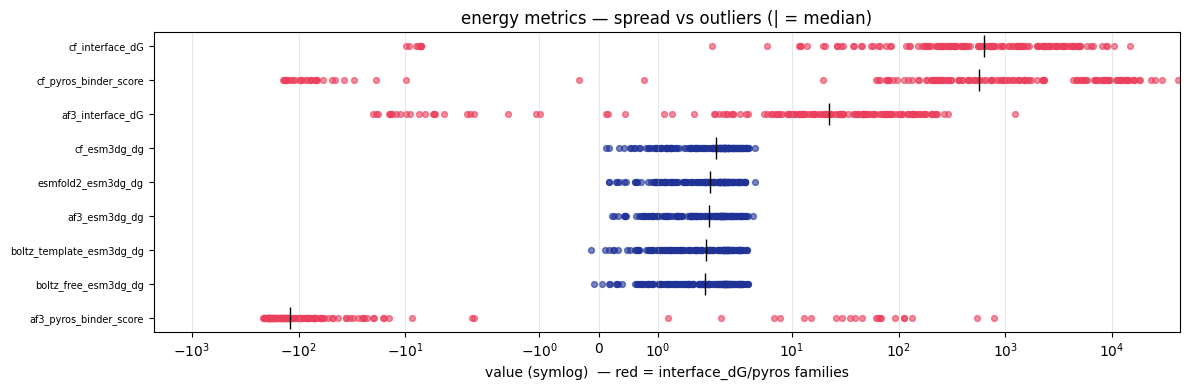

In [ ]:
display(outlier_table(raw, scale="energy"))
plot_outliers(raw, scale="energy");

## 6. Cluster association

Does whole-profile sample clustering line up with `binder_type` / `dataset`? 
ARI ~ 0 means no; `block` lists the k=2 split-off samples.

In [ ]:
ari, block = cluster_association(scaled)
display(ari)
print("split-off block:", len(block))
display(block)

,k,ARI_binder_type,ARI_dataset,ARI_source
0,2,-0.002421,0.006204,0.006204
1,4,0.006465,0.027363,0.027363
2,6,0.009269,0.045366,0.045366


split-off block: 2


,sample,binder_type,dataset,source
0,Nb_aSyn2_aSyn,Binder,sabdab_nb,sabdab
1,nb_s508757_cdr12_gliadin_8mer,Design,germinal0,germinal
